In [229]:
# Подгрузим пакеты
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

Задание 1.

In [230]:
file = 'HR.csv'
df = pd.read_csv(file, on_bad_lines='skip')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


Видим, что данные чистые, без пропусков.

Задание 2.

In [232]:
df_num = df[['satisfaction_level','last_evaluation','number_project','average_montly_hours','time_spend_company','Work_accident','left','promotion_last_5years']]
df_num.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [233]:
df_num.mode()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
0,0.1,0.55,4.0,135,3.0,0.0,0.0,0.0
1,NaN,NaN,NaN,156,NaN,NaN,NaN,NaN


Задание 3.

In [263]:
# расчет корреляционной матрицы
cor_mat = round(df_num.corr(), 3)
cor_mat

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000,0.105,-0.143,-0.020,-0.101,0.059,-0.388,0.026
last_evaluation,0.105,1.000,0.349,0.340,0.132,-0.007,0.007,-0.009
number_project,-0.143,0.349,1.000,0.417,0.197,-0.005,0.024,-0.006
average_montly_hours,-0.020,0.340,0.417,1.000,0.128,-0.010,0.071,-0.004
time_spend_company,-0.101,0.132,0.197,0.128,1.000,0.002,0.145,0.067
Work_accident,0.059,-0.007,-0.005,-0.010,0.002,1.000,-0.155,0.039
left,-0.388,0.007,0.024,0.071,0.145,-0.155,1.000,-0.062
promotion_last_5years,0.026,-0.009,-0.006,-0.004,0.067,0.039,-0.062,1.000


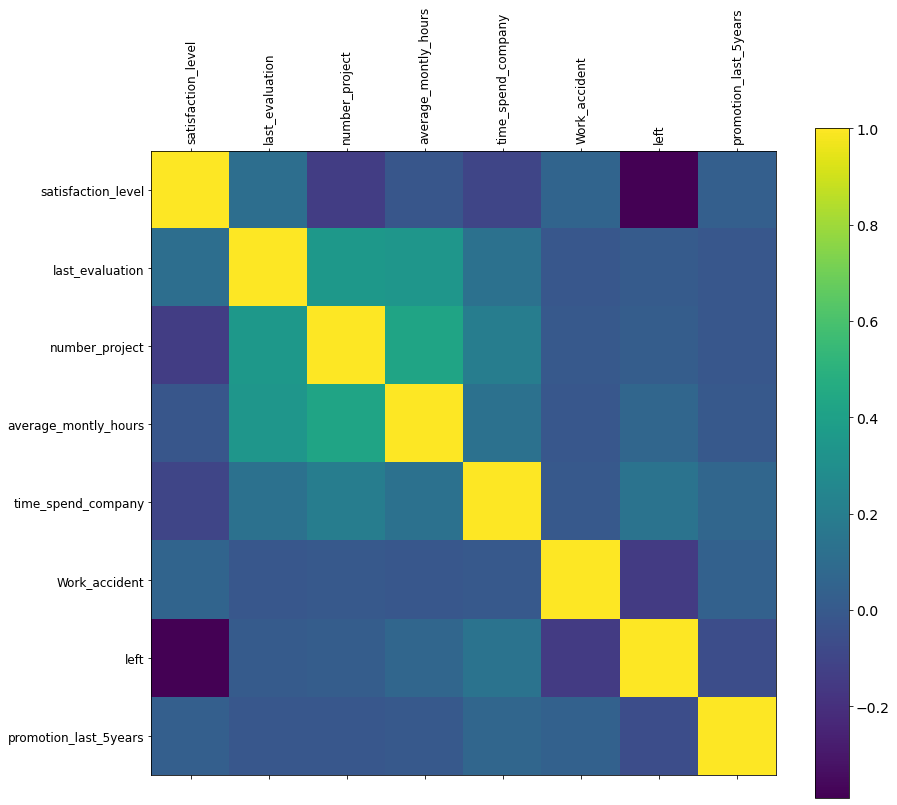

In [235]:
# визуализация корреляционной матрицы
fig = plt.figure(figsize=(14, 12))
plt.matshow(cor_mat, fignum=fig.number)
plt.xticks(range(df_num.shape[1]), df_num.columns, fontsize=12, rotation=90)
plt.yticks(range(df_num.shape[1]), df_num.columns, fontsize=12)
col_bar = plt.colorbar()
col_bar.ax.tick_params(labelsize=14)

<AxesSubplot:>

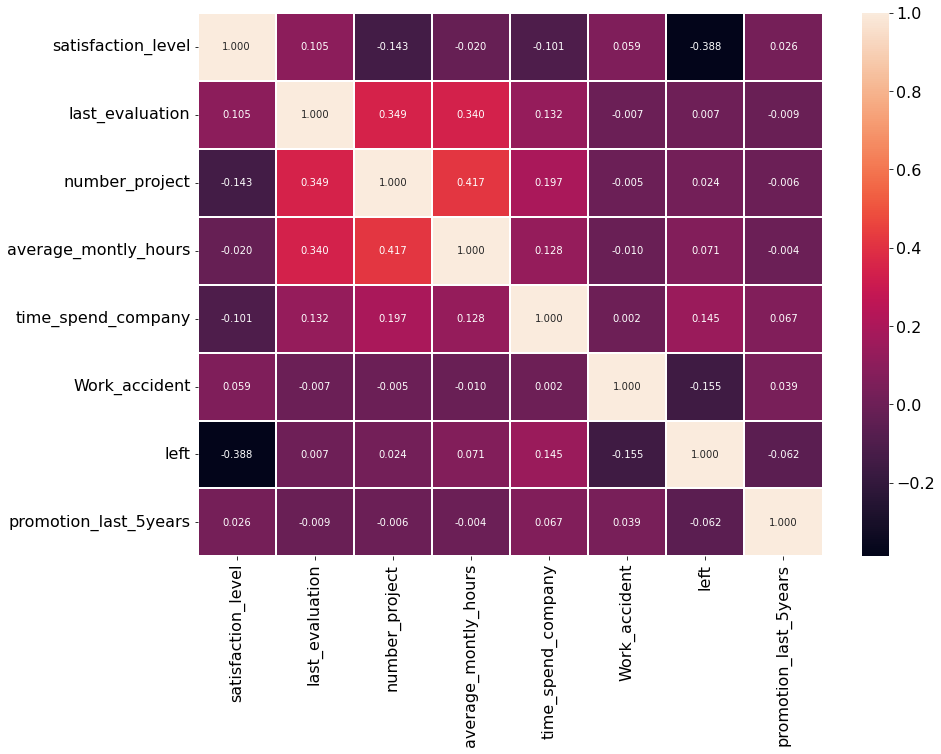

In [265]:
# выведем корреляционную матрицу в виде 'тепловой карты'
sns.heatmap(cor_mat, annot = True, fmt = '.3f', linewidths=2)


Наиболее коррелированные:
- average_montly_hours	и number_project = 0.417
- left и satisfaction_level = -0.388(обратная зависимость)

Наименее коррелированы:
- Work_accident	и time_spend_company = 0.002
- promotion_last_5years	и average_montly_hours	= -0,004
- Work_accident	и number_project = -0,005

Задание 4.

In [237]:
# сколько сотрудников работает в каждом департаменте
df.groupby('department')['department'].count()

department
IT             1227
RandD           787
accounting      767
hr              739
management      630
marketing       858
product_mng     902
sales          4140
support        2229
technical      2720
Name: department, dtype: int64

Задание 5.

In [238]:
# распределение сотрудников по зарплатам
df_sal = df.groupby('salary')['salary'].count()
df_sal

salary
high      1237
low       7316
medium    6446
Name: salary, dtype: int64

<AxesSubplot:xlabel='salary'>

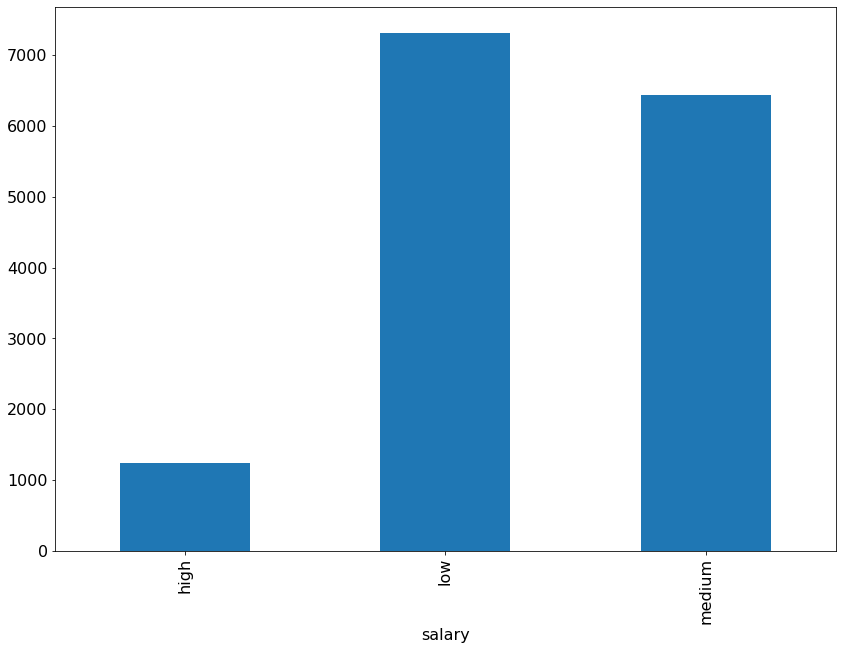

In [239]:
df_sal.plot(kind="bar")

Задание 6.

In [262]:
# Распределение сотрудников по зарплатам в каждом департаменте по отдельности
df_dep = df.groupby([df['department'],df['salary']])[['salary']].count()
df_dep

salary
department  salary        
IT          high        83
            low        609
            medium     535
RandD       high        51
            low        364
            medium     372
accounting  high        74
            low        358
            medium     335
hr          high        45
            low        335
            medium     359
management  high       225
            low        180
            medium     225
marketing   high        80
            low        402
            medium     376
product_mng high        68
            low        451
            medium     383
sales       high       269
            low       2099
            medium    1772
support     high       141
            low       1146
            medium     942
technical   high       201
            low       1372
            medium    1147

<AxesSubplot:ylabel='department,salary'>

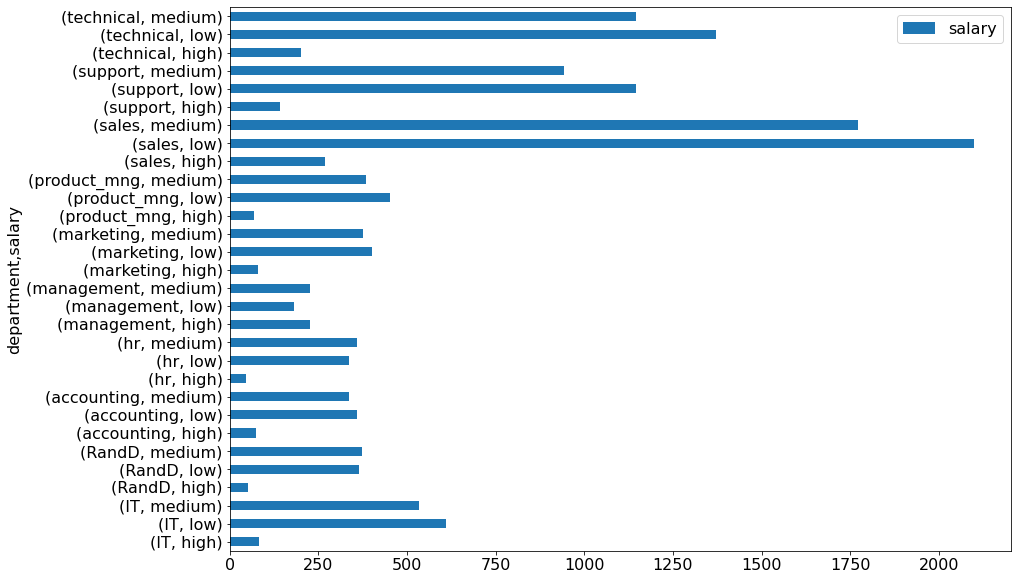

In [241]:
large = 16; med = 16; small = 12
params = {'axes.titlesize': large,
          'legend.fontsize': med,
          'figure.figsize': (14, 10),
          'axes.labelsize': med,
          'axes.titlesize': med,
          'xtick.labelsize': med,
          'ytick.labelsize': med,
          'figure.titlesize': large}
plt.rcParams.update(params)
df_dep.plot(kind='barh')

Задание 7.

Проверим гипотезу, что сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом

In [242]:
df_h = df['average_montly_hours'][df['salary'] == 'high']
df_h

72       149
111      289
189      156
267      129
306      149
        ... 
14829    148
14868    130
14902    159
14941    131
14980    238
Name: average_montly_hours, Length: 1237, dtype: int64

In [243]:
df_l = df['average_montly_hours'][df['salary'] == 'low']
df_l

0        157
3        223
4        159
5        153
6        247
        ... 
14994    151
14995    160
14996    143
14997    280
14998    158
Name: average_montly_hours, Length: 7316, dtype: int64

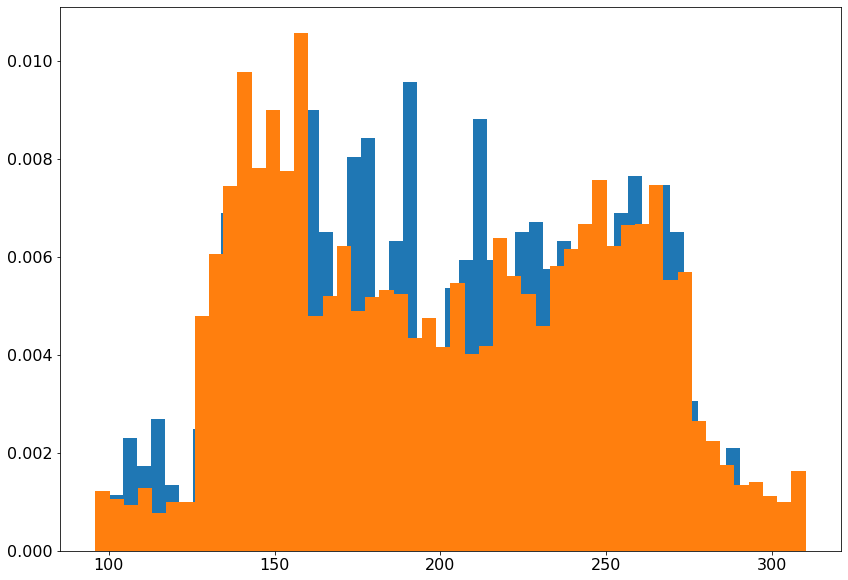

In [244]:
plt.hist(df_h, bins=50, density=True);
plt.hist(df_l, bins=50, density=True);

По гистограмме видно, что разницы почти нет. H0 - гипотеза, что сотрудники с высоким окладом проводят на работе столько же времени, что и  сотрудники с низким окладом. H1 - гипотеза, что сотрудники с высоким окладом проводят на работе больше времени, чем  сотрудники с низким окладом

In [245]:
# Тест Шапиро-Уилка: Проверяет распределены ли данные по нормальному закону.
stat, p = stats.shapiro(df_h)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Вероятно нормальное распределение')
else:
    print('Вероятно не нормальное распределение')

stat=0.971, p=0.000
Вероятно не нормальное распределение


In [246]:
stat, p = stats.shapiro(df_l)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Вероятно нормальное распределение')
else:
    print('Вероятно не нормальное распределение')

stat=0.960, p=0.000
Вероятно не нормальное распределение


C:\Users\brita\anaconda3\lib\site-packages\scipy\stats\morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [247]:
# Применим непараметрические критерий: Тест Манна-Уитни
stat, p = stats.mannwhitneyu(df_h, df_l)

print(f"Статистика = {stat:.3f}, p = {p:.6f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу, распределения, вероятно, одинаковые')
else:
    print('Отклоняем нулевую гипотезу, распределения, вероятно, различаются')

Статистика = 4507096.500, p = 0.824133
Не отклоняем нулевую гипотезу, распределения, вероятно, одинаковые


Вывод: сотрудники с высоким окладом проводят на работе столько же времени, что и  сотрудники с низким окладом.

Задание 8.

In [248]:
# Доля сотрудников с повышением за последние 5 лет среди уволившихся сотрудников
df_left = df[df['left'] == 1]
num = len(df_left[df_left['promotion_last_5years'] == 1])/len(df_left)
print(f'{num:.6f}')

0.005321


In [249]:
# Средняя степень удовлетворенности
sat = df_left['satisfaction_level'].mean()
print(f'{sat:.6f}')

0.440098


In [250]:
# Среднее количество проектов
proj = df_left['number_project'].mean()
print(f'{proj:.6f}')

3.855503


In [251]:
# Доля сотрудников с повышением за последние 5 лет среди неуволившихся сотрудников
df_work = df[df['left'] == 0]
num_ = len(df_work[df_work['promotion_last_5years'] == 1])/len(df_work)
print(f'{num_:.6f}')

0.026251


In [252]:
# Средняя степень удовлетворенности
sat_ = df_work['satisfaction_level'].mean()
print(f'{sat_:.6f}')

0.666810


In [253]:
# Среднее количество проектов
proj_ = df_work['number_project'].mean()
print(f'{proj_:.6f}')

3.786664


Выводы:
Повышение влияет на увольнение сотрудников (среди повышенных сотрудников меньше уволившихся).
Средняя степень удовлетворенности неуволившихся сотрудников выше (логично, значит им нет смысла увольняться).
Среднее количество проектов примерно однираково ( в пределах статистической погрешности).

Задание 9.

Построиv модель LDA, предсказывающую уволился ли сотрудник на основе имеющихся факторов (кроме department и salary)

In [254]:
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

In [255]:
df_left = pd.array(df_num['left'])

In [256]:
X_train, X_test, y_train, y_test = train_test_split(df_num[['satisfaction_level','last_evaluation','number_project',
                                                            'average_montly_hours','time_spend_company','Work_accident',
                                                            'promotion_last_5years']], df_left, test_size=0.30)

In [257]:
lda = LinearDiscriminantAnalysis()

In [258]:
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [259]:
result = pd.DataFrame([y_test, lda.predict(X_test)]).T
result

,0,1
0,1,0
1,0,1
2,0,0
3,0,0
4,0,0
...,...,...
4495,0,0
4496,0,0
4497,0,0
4498,0,1


In [260]:
print(f'{accuracy_score(y_test, lda.predict(X_test)):.6f}')

0.764444


In [267]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

In [273]:
# Оценим, насколько хорошо модель работает, используя стратифицированную k-кратную перекрестную проверку.
cv = RepeatedStratifiedKFold(n_splits= 10, n_repeats = 3, random_state = 1)
scores = cross_val_score(lda, X_test, y_test, scoring='accuracy', cv=cv,n_jobs=-1)
print(np.mean(scores))

0.7657037037037037


Вывод: Результат получился относительно невысоким, хотя это было предположить по корреляционной матрице, где Ккормакс = 0.42, что говорит о том, что признаки мало связаны друг с другом и на увольнение мало влияют,следовательно, результат мало предсказуем.